# 💳 Fraude em Cartões de Crédito
**Liga de Data Science — Mini Projeto**  
**Dataset:** Credit Card Fraud Detection (Kaggle)  
**Equipe:** Gleicy, Matheus, Renan, Victor  
**Prazo:** 19/06

---

###Informações sobre o Dataset


*   Linhas: 284.807 transações realizadas em 2013; Colunas: 31
*   V1 a V28 → variáveis já transformadas por PCA (nomes originais ocultados por privacidade)
*   Time: segundos após o ínicio da transação
*   Amount: valor da transação (euros)
*   Class: transação legítima = 0; fraude = 1



## Sprint 1 — Limpeza e Tratamento dos Dados
**Responsáveis:** Gleicy + Matheus  
**Prazo:** 01–05/06

###1.1 - Imports e carregamento

In [1]:
import pandas as pd              #manipular dados
import numpy as np               #cálculo numérico, matrizes, etc
import matplotlib.pyplot as plt  #criar e visualizar gráficos
import seaborn as sns            #criar e visualizar gráficos
from scipy import stats          #matematica avançada
import kagglehub                 #permite acessar e importar arquivos do kaggle!

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud", "creditcard.csv")
# lendo o arquivo do kaggle
df = pd.read_csv(path)

#Carregamos e conhecemos um pouco do dataset - noção de linhas e colunas
print('Shape: linhas, colunas')
print('Shape:', df.shape)
df.head()

100%|██████████| 66.0M/66.0M [00:00<00:00, 96.4MB/s]

Extracting zip of creditcard.csv...


Shape: linhas, colunas
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


###1.2 - Análise exploratória

In [2]:
#Vendo os tipos de dados do dataset
print('====Tipos de dados====')
print()
print(df.dtypes)

#Estatísticas descritivas
print()
print('=========================Estatísticas descritivas========================')
print()
print(df.describe().round(2))

====Tipos de dados====

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

=========================Estatísticas descritivas========================

            Time         V1         V2         V3         V4         V5  \
count  284807.00  284807.00  284807.00  284807.00  284807.00  284807.00   
mean    94813.86       0.00       0.00      -0.00       0.00       0.00   
std     47488.15       1.96       1.65       1.52       1.42       1.38   
min         0.00     -56.41 

In [3]:
# Verificando proporção de transação legítima e fraude.

print('======= DISTRIBUIÇÃO DO ALVO =======')
conta = df['Class'].value_counts()
print(conta)
print()
print(f'Proporção de fraude: {df["Class"].mean()*100:.3f}%')
print(f'Proporção legítima:  {(1-df["Class"].mean())*100:.3f}%')

======= DISTRIBUIÇÃO DO ALVO =======
Class
0    284315
1       492
Name: count, dtype: int64

Proporção de fraude: 0.173%
Proporção legítima:  99.827%


////////// O dataset está muito desbalanceado, é preciso arrumar isso. A solução que encontramos foi utilizar SMOTE para criar fraudes artificias (mas baseadas nas reais da amostra) e assim deixar o dataset proporcional e pronto para o ML.

###1.3 - Procura por nulos e duplicatas

In [4]:
#Nulos

print('==========VERIFICAÇAO DE VALORES NULOS===============')
print()
nulos = df.isnull().sum()
print(f'Total de valores nulos: {nulos.sum()}')
print()

#Duplicadas

print('==============LINHAS DUPLICADAS======================')
print()
dupe = df.duplicated().sum()
print(f'Total de linhas duplicadas: {dupe}')

==========VERIFICAÇAO DE VALORES NULOS===============

Total de valores nulos: 0

==============LINHAS DUPLICADAS======================

Total de linhas duplicadas: 1081


###1.4 - Limpeza


In [5]:
# Vamos retirar as duplicatas, mas criando uma cópia do df original.

df_nova = df.copy()

antes = len(df_nova)   #contagem das linhas antes
df_nova = df_nova.drop_duplicates().reset_index(drop=True)
depois = len(df_nova)  #contagem após a limpeza

print(f'Linhas duplicadas: {antes - depois}')
print(f'Linhas antes da limpeza: {antes}')
print(f'Linhas após a limpeza: {depois}')


Linhas duplicadas: 1081
Linhas antes da limpeza: 284807
Linhas após a limpeza: 283726


###1.5 - Normalização das colunas Time e Amount

É possível notar que com exceção dessas duas colunas, o dataset está bem padronizado. Time e amount estao com escalas muito divergntes das outras variáveis e serão padronizadas.

In [6]:
from sklearn.preprocessing import StandardScaler   #transforma para média=0 e desvio padrão=1

scaler = StandardScaler()

# Criamos colunas novas para não perder os valores originais
df_nova['Time_scaled']   = scaler.fit_transform(df_nova[['Time']])
df_nova['Amount_scaled'] = scaler.fit_transform(df_nova[['Amount']])

# Remove as colunas originais e deixa só as que criamos!
df_nova = df_nova.drop(['Time', 'Amount'], axis=1)

print('Colunas após normalização:')
print(df_nova.columns.tolist())
print(f'Shape final: {df_nova.shape}')


Colunas após normalização:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Time_scaled', 'Amount_scaled']
Shape final: (283726, 31)


In [7]:
df_nova.head(2)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Time_scaled,Amount_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,-1.996823,0.244200
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-1.996823,-0.342584


In [8]:
# 1.1 Imports

# 1.2 Carregamento do dataset

# 1.3 Conhecendo os dados (shape, dtypes, describe)

# 1.4 Verificando nulos e duplicatas

# 1.5 Limpeza (remover duplicatas)

# 1.6 Normalização de Time e Amount


## Sprint 2 — Análise dos Dados
**Responsáveis:** Renan + Victor  
**Prazo:** 06–10/06

###2.1 Visualizar o desbalanceamento

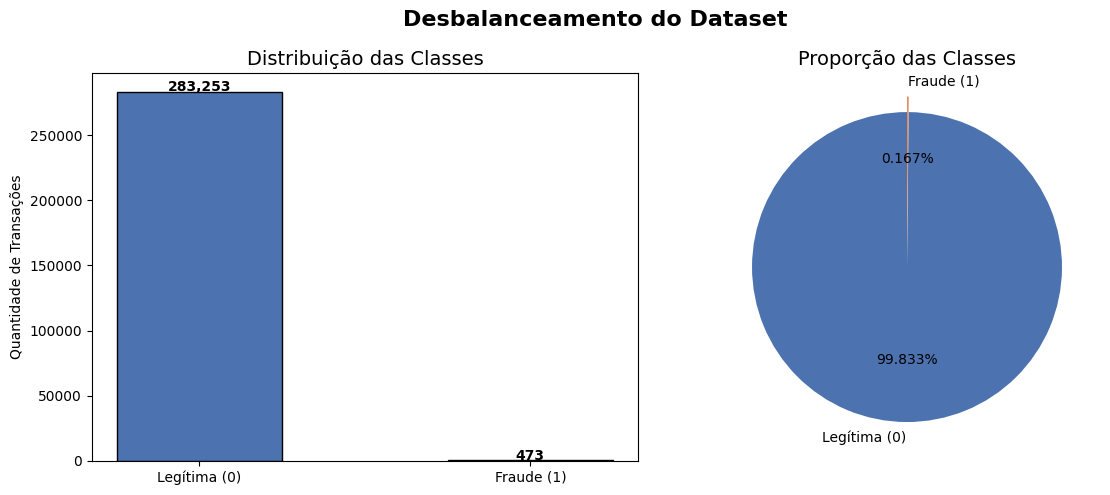

Legítimas : 283,253  (99.833%)
Fraudes   : 473  (0.167%)
Razão     : 1 fraude para cada 598 transações legítimas


In [9]:
# 2.1 Visualizar o desbalanceamento

contagem = df_nova['Class'].value_counts()
labels   = ['Legítima (0)', 'Fraude (1)']
cores    = ['#4C72B0', '#DD8452']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
axes[0].bar(labels, contagem.values, color=cores, edgecolor='black', width=0.5)
axes[0].set_title('Distribuição das Classes', fontsize=14)
axes[0].set_ylabel('Quantidade de Transações')
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Gráfico de pizza
axes[1].pie(
    contagem.values,
    labels=labels,
    autopct='%1.3f%%',
    colors=cores,
    startangle=90,
    explode=(0, 0.1)
)
axes[1].set_title('Proporção das Classes', fontsize=14)

plt.suptitle('Desbalanceamento do Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Legítimas : {contagem[0]:,}  ({contagem[0]/len(df_nova)*100:.3f}%)')
print(f'Fraudes   : {contagem[1]:,}  ({contagem[1]/len(df_nova)*100:.3f}%)')
print(f'Razão     : 1 fraude para cada {contagem[0]//contagem[1]:.0f} transações legítimas')


###2.2 Distribuição do valor das transações (Amount)

/tmp/ipykernel_4228/4239241319.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(
/tmp/ipykernel_4228/4239241319.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


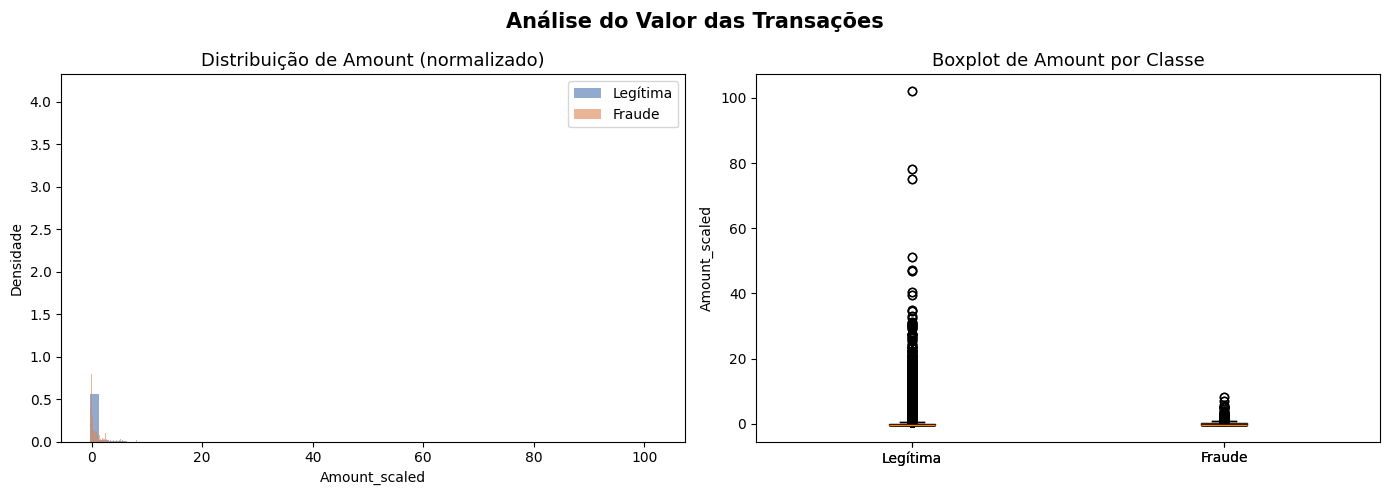

=== Estatísticas de Amount_scaled ===
          count   mean    std    min    25%    50%    75%      max
Class                                                             
0      283253.0 -0.000  1.000 -0.353 -0.331 -0.265 -0.044  102.248
1         473.0  0.141  1.039 -0.353 -0.349 -0.314  0.070    8.137


In [10]:
# 2.2 Distribuição do valor das transações (Amount)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

legit  = df_nova[df_nova['Class'] == 0]['Amount_scaled']
fraude = df_nova[df_nova['Class'] == 1]['Amount_scaled']

# Histograma
axes[0].hist(legit,  bins=60, alpha=0.6, color='#4C72B0', label='Legítima', density=True)
axes[0].hist(fraude, bins=60, alpha=0.6, color='#DD8452', label='Fraude',   density=True)
axes[0].set_title('Distribuição de Amount (normalizado)', fontsize=13)
axes[0].set_xlabel('Amount_scaled')
axes[0].set_ylabel('Densidade')
axes[0].legend()

# Boxplot
axes[1].boxplot(
    [legit, fraude],
    labels=['Legítima', 'Fraude'],
    patch_artist=True,
    boxprops=dict(facecolor='#4C72B0', alpha=0.6),
    medianprops=dict(color='black', linewidth=2)
)
# Colorir o segundo box de laranja
bp = axes[1].boxplot(
    [legit, fraude],
    labels=['Legítima', 'Fraude'],
    patch_artist=True
)
for patch, color in zip(bp['boxes'], cores):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_title('Boxplot de Amount por Classe', fontsize=13)
axes[1].set_ylabel('Amount_scaled')

plt.suptitle('Análise do Valor das Transações', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== Estatísticas de Amount_scaled ===')
print(df_nova.groupby('Class')['Amount_scaled'].describe().round(3))


###2.3 Gráfico Time vs Amount destacando fraudes

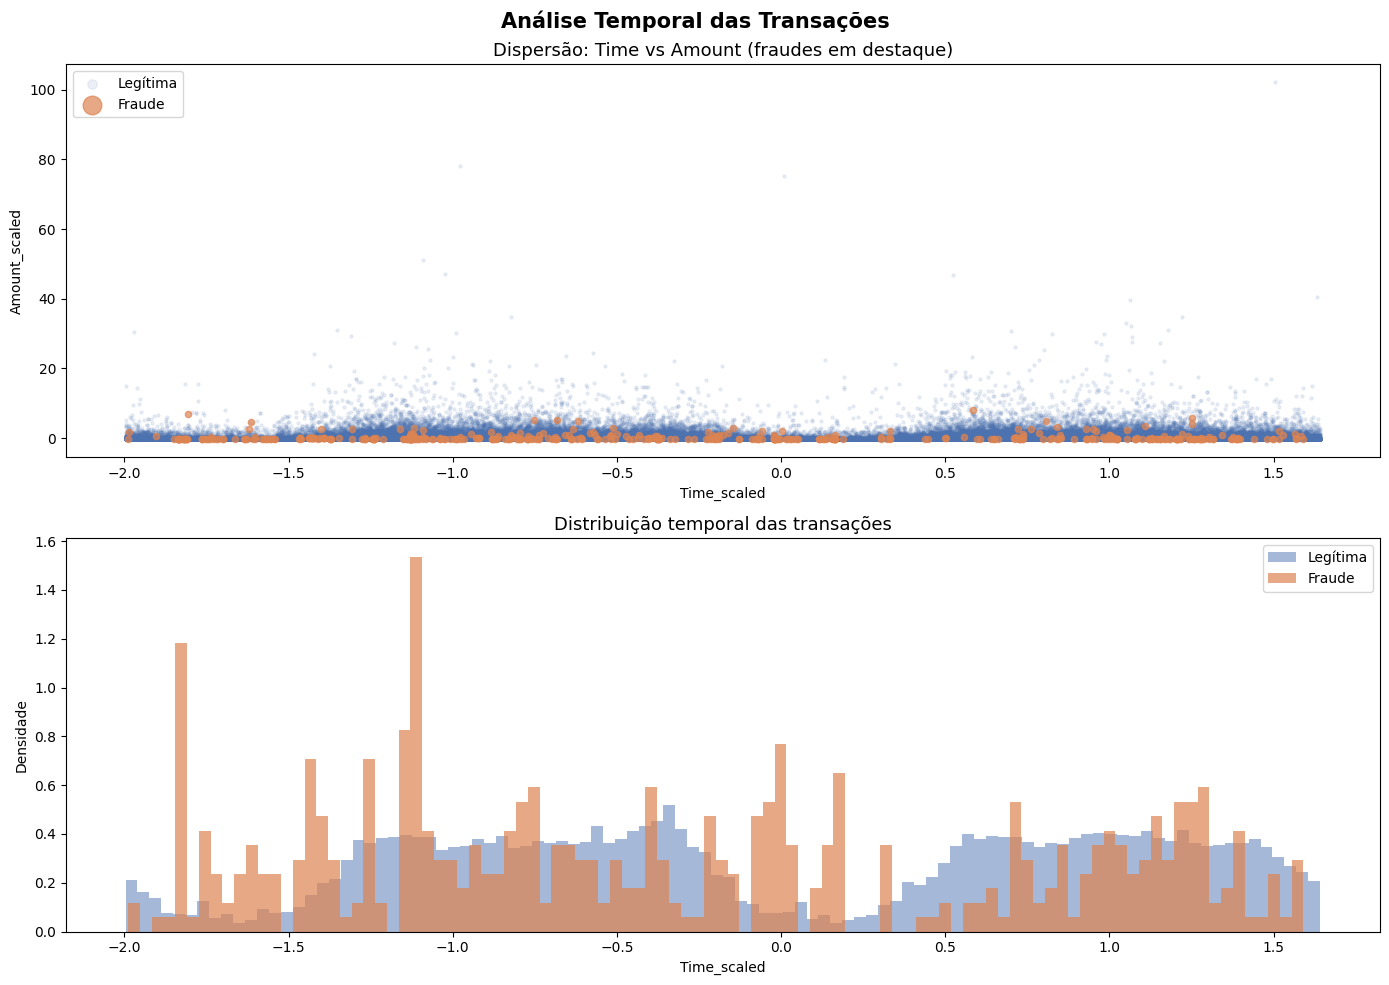

In [11]:
# 2.3 Gráfico Time vs Amount destacando fraudes

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

legit_df  = df_nova[df_nova['Class'] == 0]
fraude_df = df_nova[df_nova['Class'] == 1]

# Scatter: Time vs Amount
axes[0].scatter(legit_df['Time_scaled'],  legit_df['Amount_scaled'],
                alpha=0.1, s=5,  color='#4C72B0', label='Legítima')
axes[0].scatter(fraude_df['Time_scaled'], fraude_df['Amount_scaled'],
                alpha=0.7, s=20, color='#DD8452', label='Fraude', zorder=5)
axes[0].set_title('Dispersão: Time vs Amount (fraudes em destaque)', fontsize=13)
axes[0].set_xlabel('Time_scaled')
axes[0].set_ylabel('Amount_scaled')
axes[0].legend(markerscale=3)

# Densidade de fraudes ao longo do tempo
axes[1].hist(legit_df['Time_scaled'],  bins=100, alpha=0.5, color='#4C72B0',
             label='Legítima', density=True)
axes[1].hist(fraude_df['Time_scaled'], bins=100, alpha=0.7, color='#DD8452',
             label='Fraude',   density=True)
axes[1].set_title('Distribuição temporal das transações', fontsize=13)
axes[1].set_xlabel('Time_scaled')
axes[1].set_ylabel('Densidade')
axes[1].legend()

plt.suptitle('Análise Temporal das Transações', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.4 Matriz de Correlação

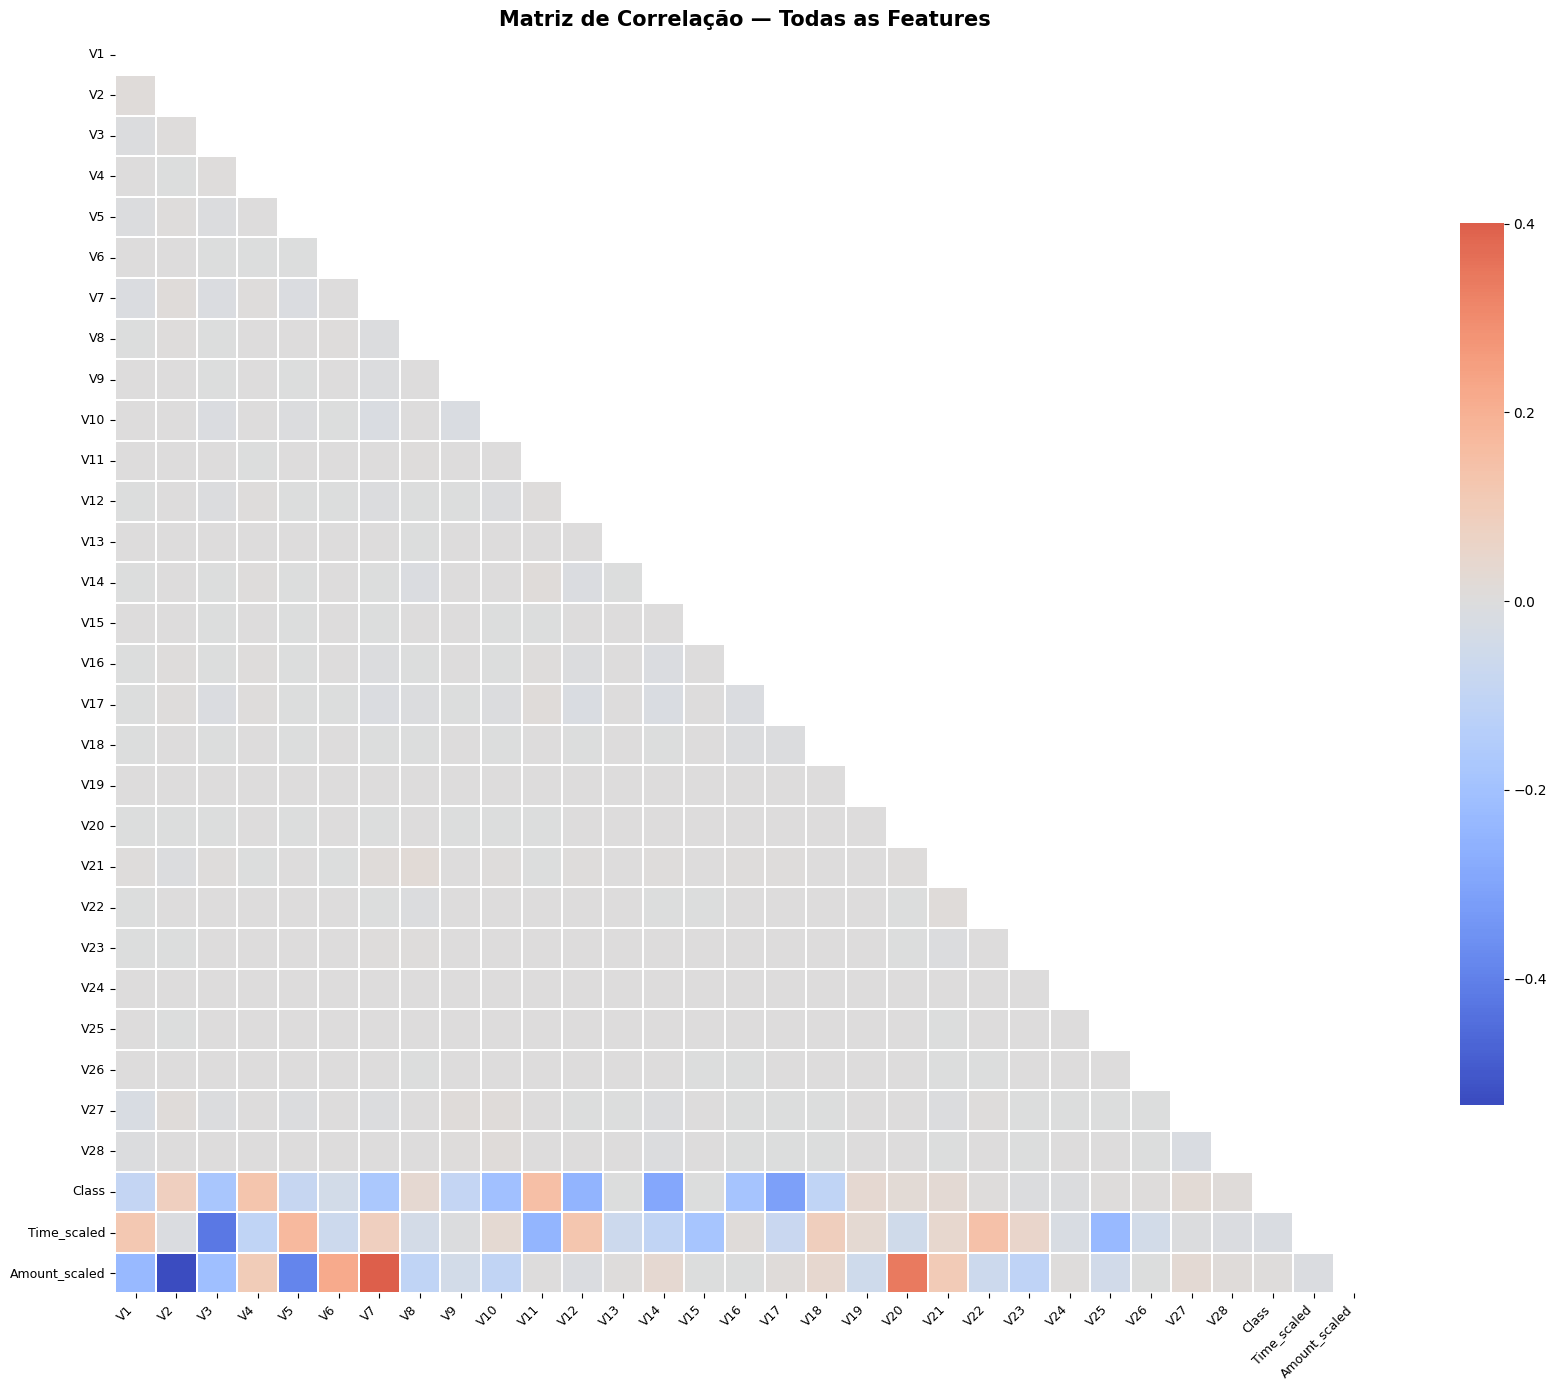

=== Top 10 features mais correlacionadas com Class ===
V17    0.3135
V14    0.2934
V12    0.2507
V10    0.2070
V16    0.1872
V3     0.1823
V7     0.1723
V11    0.1491
V4     0.1293
V18    0.1053
Name: Class, dtype: float64


In [12]:
# 2.4 Matriz de correlação

plt.figure(figsize=(18, 14))

correlacao = df_nova.corr()

mascara = np.zeros_like(correlacao, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True   # oculta o triângulo superior (redundante)

sns.heatmap(
    correlacao,
    mask=mascara,
    annot=False,          # com 30 colunas, annot polui — mude para True se quiser os números
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    square=True,
    cbar_kws={'shrink': 0.7}
)

plt.title('Matriz de Correlação — Todas as Features', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Top correlações com a classe alvo
corr_class = correlacao['Class'].drop('Class').abs().sort_values(ascending=False)
print('=== Top 10 features mais correlacionadas com Class ===')
print(corr_class.head(10).round(4))


### 2.5 Análise por hora do dia

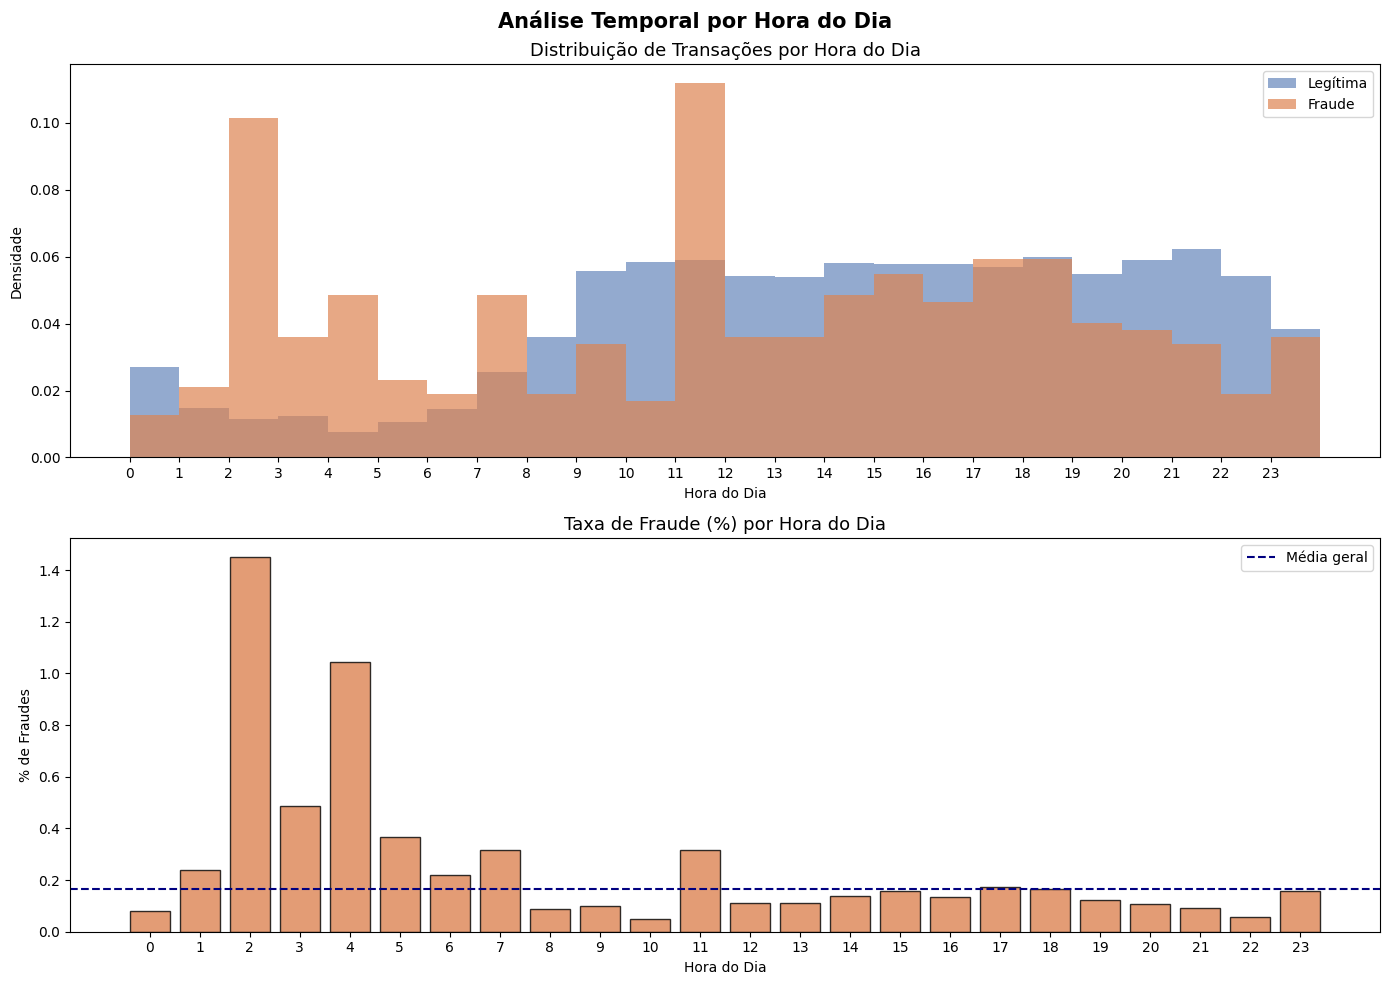

Hora com maior taxa de fraude : 2.0h (1.451%)
Hora com menor taxa de fraude : 10.0h (0.048%)


In [13]:
# 2.5 Análise por hora do dia
# Recuperamos a coluna Time original para extrair a hora

df_hora = df.copy()
df_hora = df_hora.drop_duplicates().reset_index(drop=True)

# Time está em segundos desde a primeira transação; convertemos para hora do dia (0–23)
df_hora['hora'] = (df_hora['Time'] // 3600) % 24

legit_h  = df_hora[df_hora['Class'] == 0]
fraude_h = df_hora[df_hora['Class'] == 1]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Volume de transações por hora
axes[0].hist(legit_h['hora'],  bins=24, range=(0, 24), alpha=0.6,
             color='#4C72B0', label='Legítima', density=True)
axes[0].hist(fraude_h['hora'], bins=24, range=(0, 24), alpha=0.7,
             color='#DD8452', label='Fraude',   density=True)
axes[0].set_title('Distribuição de Transações por Hora do Dia', fontsize=13)
axes[0].set_xlabel('Hora do Dia')
axes[0].set_ylabel('Densidade')
axes[0].set_xticks(range(0, 24))
axes[0].legend()

# Taxa de fraude por hora
taxa_fraude = df_hora.groupby('hora')['Class'].mean() * 100
axes[1].bar(taxa_fraude.index, taxa_fraude.values, color='#DD8452', edgecolor='black', alpha=0.8)
axes[1].set_title('Taxa de Fraude (%) por Hora do Dia', fontsize=13)
axes[1].set_xlabel('Hora do Dia')
axes[1].set_ylabel('% de Fraudes')
axes[1].set_xticks(range(0, 24))
axes[1].axhline(y=df_hora['Class'].mean()*100, color='navy',
                linestyle='--', linewidth=1.5, label='Média geral')
axes[1].legend()

plt.suptitle('Análise Temporal por Hora do Dia', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

hora_pico = taxa_fraude.idxmax()
print(f'Hora com maior taxa de fraude : {hora_pico}h ({taxa_fraude[hora_pico]:.3f}%)')
print(f'Hora com menor taxa de fraude : {taxa_fraude.idxmin()}h ({taxa_fraude.min():.3f}%)')


## Sprint 3 — Modelos de Machine Learning
**Responsáveis:** Time todo  
**Prazo:** 11–15/06

### 3.1 Preparação: separar X e y, treino e teste

In [14]:
from sklearn.model_selection import train_test_split

# X = tudo que o modelo usa para aprender
# y = o que ele precisa prever
X = df_nova.drop('Class', axis=1)
y = df_nova['Class']

print(f'Features (X): {X.shape}')
print(f'Alvo    (y): {y.shape}')

# Treino (80%) e teste (20%)
# stratify=y → mantém a proporção de fraudes em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'\nTreino: {X_train.shape[0]:,} transações')
print(f'Teste:  {X_test.shape[0]:,} transações')
print(f'Fraudes no treino: {y_train.sum()} ({y_train.mean()*100:.3f}%)')
print(f'Fraudes no teste:  {y_test.sum()} ({y_test.mean()*100:.3f}%)')


Features (X): (283726, 30)
Alvo    (y): (283726,)

Treino: 226,980 transações
Teste:  56,746 transações
Fraudes no treino: 378 (0.167%)
Fraudes no teste:  95 (0.167%)


### 3.2 Aplicando SMOTE (treino)

In [15]:
from imblearn.over_sampling import SMOTE

print('ANTES do SMOTE:')
print(f'  Legítimas no treino: {(y_train==0).sum():,}')
print(f'  Fraudes no treino:   {(y_train==1).sum():,}')

# SMOTE cria fraudes sintéticas interpolando entre fraudes reais
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('\nDEPOIS do SMOTE:')
print(f'  Legítimas no treino: {(y_train_bal==0).sum():,}')
print(f'  Fraudes no treino:   {(y_train_bal==1).sum():,}')
print(f'  Proporção:           50% / 50%')
print('\nTeste ainda intocado:')
print(f'  Fraudes no teste: {y_test.sum()} reais ({y_test.mean()*100:.3f}%)')

ANTES do SMOTE:
  Legítimas no treino: 226,602
  Fraudes no treino:   378

DEPOIS do SMOTE:
  Legítimas no treino: 226,602
  Fraudes no treino:   226,602
  Proporção:           50% / 50%

Teste ainda intocado:
  Fraudes no teste: 95 reais (0.167%)


### 3.3 Modelo 1 — Regressão Logística

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, recall_score, precision_score,
                             average_precision_score)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_bal, y_train_bal)

y_pred_lr  = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print('=== REGRESSÃO LOGÍSTICA ===')
print(classification_report(y_test, y_pred_lr,
      target_names=['Legítima', 'Fraude']))
print(f'AUC-ROC:          {roc_auc_score(y_test, y_proba_lr):.4f}')
print(f'AUC-PR:           {average_precision_score(y_test, y_proba_lr):.4f}')
print(f'Recall (fraude):  {recall_score(y_test, y_pred_lr):.4f}')

=== REGRESSÃO LOGÍSTICA ===
              precision    recall  f1-score   support

    Legítima       1.00      0.97      0.99     56651
      Fraude       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

AUC-ROC:          0.9619
AUC-PR:           0.6768
Recall (fraude):  0.8737


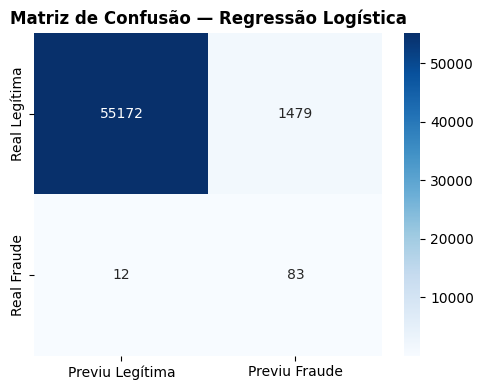

Fraudes detectadas (VP):  83
Fraudes perdidas   (FN):  12  
Alarmes falsos     (FP):  1479


In [17]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previu Legítima', 'Previu Fraude'],
            yticklabels=['Real Legítima', 'Real Fraude'])
ax.set_title('Matriz de Confusão — Regressão Logística', fontweight='bold')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm_lr.ravel()
print(f'Fraudes detectadas (VP):  {tp}')
print(f'Fraudes perdidas   (FN):  {fn}  ')
print(f'Alarmes falsos     (FP):  {fp}')

### 3.4 Modelo 2 — Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier

# n_estimators=100 → 100 árvores de decisão
# n_jobs=-1 → usa todos os núcleos do processador (mais rápido)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('=== RANDOM FOREST ===')
print(classification_report(y_test, y_pred_rf,
      target_names=['Legítima', 'Fraude']))
print(f'AUC-ROC:          {roc_auc_score(y_test, y_proba_rf):.4f}')
print(f'AUC-PR:           {average_precision_score(y_test, y_proba_rf):.4f}')
print(f'Recall (fraude):  {recall_score(y_test, y_pred_rf):.4f}')

=== RANDOM FOREST ===
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     56651
      Fraude       0.91      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746

AUC-ROC:          0.9609
AUC-PR:           0.8123
Recall (fraude):  0.7579


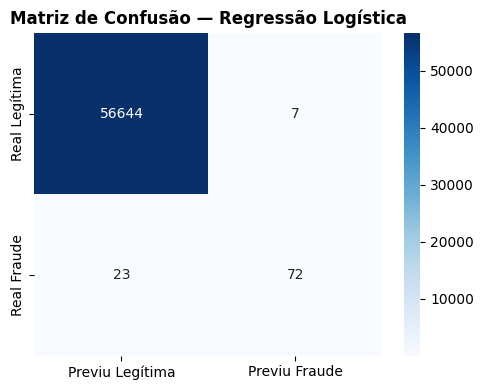

Fraudes detectadas (VP):  72
Fraudes perdidas   (FN):  23  ← erro
Alarmes falsos     (FP):  7


In [19]:
cm_lr = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previu Legítima', 'Previu Fraude'],
            yticklabels=['Real Legítima', 'Real Fraude'])
ax.set_title('Matriz de Confusão — Regressão Logística', fontweight='bold')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm_lr.ravel()
print(f'Fraudes detectadas (VP):  {tp}')
print(f'Fraudes perdidas   (FN):  {fn}  ← erro')
print(f'Alarmes falsos     (FP):  {fp}')

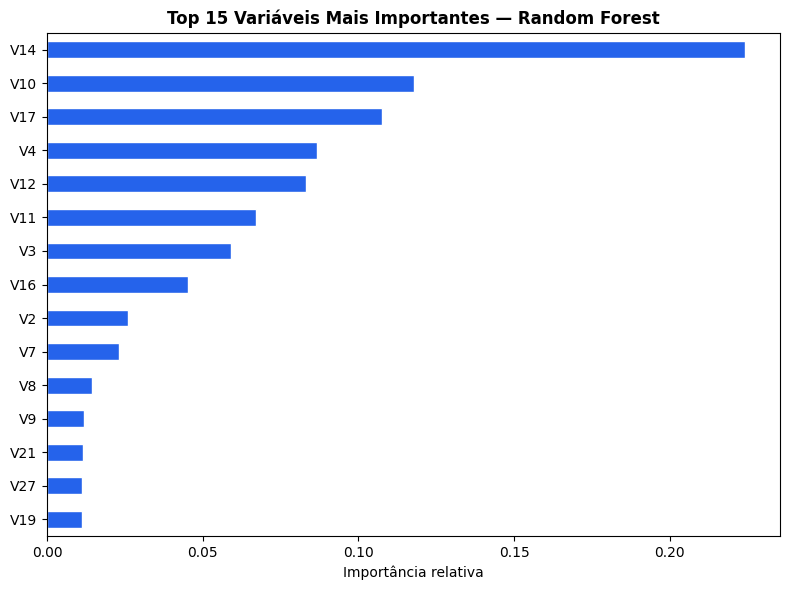

In [20]:
# Importância das variáveis — Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='#2563EB', edgecolor='white')
plt.title('Top 15 Variáveis Mais Importantes — Random Forest', fontweight='bold')
plt.xlabel('Importância relativa')
plt.tight_layout(); plt.show()

### 3.6 Comparação final dos modelos

In [22]:
from sklearn.metrics import accuracy_score

resultados = pd.DataFrame({
    'Modelo': [
        'Regressão Logística',
        'Random Forest',

    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),

    ],
    'Precisão': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),

    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf),

    ],
    'Fraudes detectadas': [
        int(recall_score(y_test, y_pred_lr)       * y_test.sum()),
        int(recall_score(y_test, y_pred_rf)        * y_test.sum()),

    ],
    'Fraudes perdidas': [
        y_test.sum() - int(recall_score(y_test, y_pred_lr)       * y_test.sum()),
        y_test.sum() - int(recall_score(y_test, y_pred_rf)        * y_test.sum()),

    ]
}).round(4)

print(resultados.to_string(index=False))

             Modelo  Recall  Precisão  AUC-ROC  Fraudes detectadas  Fraudes perdidas
Regressão Logística  0.8737    0.0531   0.9619                  83                12
      Random Forest  0.7579    0.9114   0.9609                  72                23


## Sprint 4 — Streamlit
**Responsáveis:** Gleicy + Matheus  
**Prazo:** 16–19/06

## Conclusões